In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap
import seaborn as sns
from sklearn.manifold import TSNE, MDS


from src.datasets import QM9Dataset
from src.non_euclidean import Riemann

In [3]:
qm9 = QM9Dataset(limit=2000, sampling_strategy="stratified", stratify_by=["gap", "num_atoms"], descriptors=["soap"])
df = qm9.load()

2026-05-01 10:09:27.469 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-01 10:09:27.881 | INFO     | src.datasets:_sample_qm9_df:1072 - QM9 sampling complete: strategy=stratified, requested_limit=2200, returned_rows=2200.
2026-05-01 10:09:27.881 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=2200).
2026-05-01 10:09:27.884 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-01 10:09:29.296 | SUCCESS  | src.datasets:add_soap:1242 - Added SOAP embeddings and matrices.
2026-05-01 10:09:29.296 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-01 10:09:29.304 | INFO     | src.datasets:load:906 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=2000, returned_rows=2000, base_rows=2200.


In [4]:
riemann = Riemann()
spd_matrices = riemann._get_spd_matrices(df=df, descriptor="soap", n_pca=None)

2026-05-01 10:09:29.311 | INFO     | src.non_euclidean:_feature_matrices_from_df:188 - Using column: soap_matrix from df


In [5]:
X_spd = np.array(spd_matrices)
ts = TangentSpace(metric='riemann')
X_tangent = ts.fit_transform(X_spd)

KeyboardInterrupt: 

In [ ]:
import plotly.express as px
from sklearn.manifold import TSNE

# 1. Ask t-SNE for 3 dimensions instead of 2
print("Running 3D t-SNE, please wait...")
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_3d_tsne = tsne_3d.fit_transform(X_tangent) # We use X_tangent from the previous code!

# 2. Create an interactive 3D scatter plot
# We convert labels to strings so plotly treats them as distinct categories (colors)
fig = px.scatter_3d(
    x=X_3d_tsne[:, 0], 
    y=X_3d_tsne[:, 1], 
    z=X_3d_tsne[:, 2],
    title="3D t-SNE Projection of SOAP Descriptors",
    labels={'color': 'Cluster'},
    opacity=0.7
)

# Make the dots a bit smaller for 3D viewing
fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='DarkSlateGrey')))
fig.show()

Running 3D t-SNE, please wait...


In [ ]:
df['soap_matrix']

soap_matrix
list[list[f64]]
"[[0.004219, 0.012251, … 0.015778], [0.00424, 0.011623, … 0.00661], … [0.009411, 0.026753, … 0.030941]]"
"[[0.006542, 0.019619, … 0.032293], [0.005442, 0.013071, … 0.02533], … [0.011256, 0.03281, … 0.038762]]"
"[[0.004722, 0.013636, … 0.01943], [0.00601, 0.015217, … 0.029801], … [0.014321, 0.042091, … 0.028803]]"
"[[0.003741, 0.010584, … 0.006146], [0.004242, 0.011071, … 0.031746], … [0.005869, 0.017695, … 0.027991]]"
"[[0.009473, 0.027837, … 0.01803], [0.005124, 0.013136, … 0.024989], … [0.009731, 0.027568, … 0.044016]]"
…
"[[0.003678, 0.010627, … 0.008433], [0.003155, 0.008713, … 0.0145], … [0.007028, 0.019786, … 0.036492]]"
"[[0.002955, 0.008433, … 0.018808], [0.002398, 0.00616, … 0.020994], … [0.005453, 0.016702, … 0.022711]]"
"[[0.007179, 0.021166, … 0.011247], [0.003824, 0.010015, … 0.017769], … [0.00755, 0.021867, … 0.037455]]"


In [21]:
from src.non_euclidean import _feature_matrices_from_df
X_class  = _feature_matrices_from_df(df, "soap_matrix")[0]
X_manual = np.array(df['soap_matrix'].to_list()[0])

2026-05-01 10:40:35.075 | INFO     | src.non_euclidean:_feature_matrices_from_df:188 - Using column: soap_matrix from df


In [22]:
print(np.allclose(X_manual, X_class))

True


In [23]:
X = np.array(df['soap_matrix'].to_list()[0])
#mu = np.mean(X, axis=0)
#X_centered = X - mu
cov = (X.T @ X) / (X.shape[0])
print(cov)

[[6.49920698e-05 1.80280572e-04 2.03866803e-04 ... 1.15161206e-04
  3.24445901e-05 1.75335064e-04]
 [1.80280572e-04 5.00311580e-04 5.66084334e-04 ... 3.18872829e-04
  9.06403058e-05 4.86881152e-04]
 [2.03866803e-04 5.66084334e-04 6.48589270e-04 ... 3.58927544e-04
  1.09496912e-04 5.55117389e-04]
 ...
 [1.15161206e-04 3.18872829e-04 3.58927544e-04 ... 2.29580128e-04
  2.92275575e-05 2.94258585e-04]
 [3.24445901e-05 9.06403058e-05 1.09496912e-04 ... 2.92275575e-05
  6.11833423e-05 1.14531518e-04]
 [1.75335064e-04 4.86881152e-04 5.55117389e-04 ... 2.94258585e-04
  1.14531518e-04 5.02251861e-04]]


In [ ]:
spd_matrices[0]

array([[1.06499207e-03, 1.80280572e-04, 2.03866803e-04, ...,
        1.15161206e-04, 3.24445901e-05, 1.75335064e-04],
       [1.80280572e-04, 1.50031158e-03, 5.66084334e-04, ...,
        3.18872829e-04, 9.06403058e-05, 4.86881152e-04],
       [2.03866803e-04, 5.66084334e-04, 1.64858927e-03, ...,
        3.58927544e-04, 1.09496912e-04, 5.55117389e-04],
       ...,
       [1.15161206e-04, 3.18872829e-04, 3.58927544e-04, ...,
        1.22958013e-03, 2.92275575e-05, 2.94258585e-04],
       [3.24445901e-05, 9.06403058e-05, 1.09496912e-04, ...,
        2.92275575e-05, 1.06118334e-03, 1.14531518e-04],
       [1.75335064e-04, 4.86881152e-04, 5.55117389e-04, ...,
        2.94258585e-04, 1.14531518e-04, 1.50225186e-03]], shape=(252, 252))

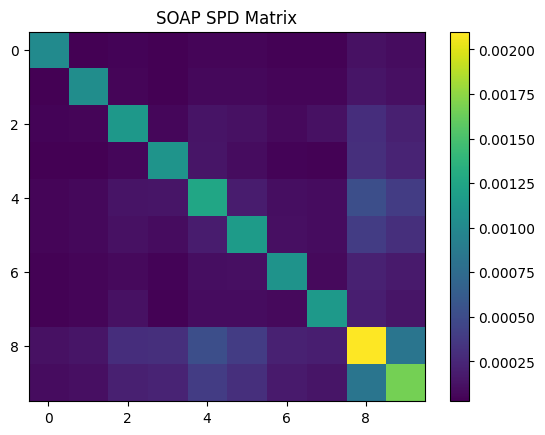

In [27]:
plt.imshow(spd_matrices[0][90:100, 90:100], aspect='auto')
plt.colorbar()
plt.title("SOAP SPD Matrix")
plt.show()